# Introdução à testes de hipótese

Um **teste de hipótese** é uma técnica estatística usada para tomar decisões sobre uma população com base em dados amostrais. Ele envolve a formulação de duas hipóteses:

- **Hipótese Nula (H₀):** Presume que não há efeito ou diferença significativa (é a hipótese que se tenta refutar).
- **Hipótese Alternativa (H₁):** Sugere que existe um efeito ou diferença significativa (é a hipótese que se tenta provar).

O objetivo do teste é determinar se os dados amostrais fornecem evidências suficientes para rejeitar a hipótese nula em favor da hipótese alternativa.

### a) P-Valor

O **p-valor** é a probabilidade de observarmos um valor estatístico tão extremo quanto ou mais extremo que o valor observado, assumindo que a hipótese nula seja verdadeira. Ele é utilizado para tomar decisões em um teste de hipótese:

- Se o p-valor for menor que o nível de significância (α), geralmente 0,05, rejeitamos a hipótese nula.
- Se o p-valor for maior ou igual ao nível de significância, não rejeitamos a hipótese nula.

O p-valor, portanto, é uma medida de evidência contra a hipótese nula.

### b) Testes Paramétricos

**Testes paramétricos** são testes de hipótese que assumem que os dados seguem uma distribuição específica (geralmente a distribuição normal). Eles são usados quando essas suposições são atendidas e incluem:

- **Teste T** (para uma ou duas amostras)
- **ANOVA** (Análise de Variância)
- **Correlação de Pearson**

Esses testes tendem a ser mais poderosos quando as suposições são válidas, pois utilizam informações adicionais sobre a distribuição dos dados.

### c) Testes Não Paramétricos

**Testes não paramétricos** não assumem uma distribuição específica para os dados, sendo mais flexíveis em relação às suposições. Eles são ideais quando os dados não seguem uma distribuição normal ou quando as amostras são pequenas. Exemplos incluem:

- **Teste de Mann-Whitney** (alternativa ao teste T para duas amostras independentes)
- **Teste de Wilcoxon** (para amostras pareadas)
- **Teste de Kruskal-Wallis** (alternativa ao ANOVA)
- **Teste Qui-Quadrado** (para variáveis categóricas)
- **Teste de Kolmogorov-Smirnov**
- **Correlação de Spearman** (alternativa ao person)

Esses testes são menos sensíveis a violações de pressupostos, mas podem ser menos poderosos comparados aos testes paramétricos quando as suposições destes últimos são atendidas.


In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [66]:
# Teste de normalidade

def test_shapiro(x):

    shapiro_stat, shapiro_p_value = stats.shapiro(x)
     # Interpretação
    if shapiro_p_value > 0.05:
        return print("Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: {}".format(shapiro_p_value))
    else:
        return print("Teste de normalidade: rejeitamos a hipótese nula (os dados não seguem uma distribuição normal). p-valor: {}".format(shapiro_p_value))
    

# Testes Paramêtricos 

**Testes paramétricos** são testes de hipótese que assumem que os dados seguem uma distribuição específica (geralmente a distribuição normal). Eles são usados quando essas suposições são atendidas e incluem:

- **Teste T** (para uma ou duas amostras)
- **ANOVA** (Análise de Variância)
- **Correlação de Pearson**

## 1. Teste T para uma amostra

- Objetivo: Verificar se a média de uma amostra difere de um valor conhecido.
- Exemplo: Suponha que você tenha uma amostra de alturas de 10 pessoas e queremos saber se a média dessas alturas é significativamente diferente de 1.70m.

#### Hipóteses:

- **Hipótese Nula (H₀)**: A média da amostra é igual ao valor referencial.  
  $H_0: \mu = 1,70 \, \text{m}$

- **Hipótese Alternativa (H₁)**: A média da amostra é diferente do valor referencial.  
  $H_1: \mu \neq 1,70 \, \text{m}$


In [56]:
sample = [1.72, 1.89, 1.78, 1.70, 1.75, 1.80, 1.85, 1.75, 1.90, 1.77]

test_shapiro(sample)

Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: 0.4349203984795892


In [57]:
t_stat, p_value = stats.ttest_1samp(sample, 1.70, alternative='two-sided') #two-sided, less ou greater

print(f"Estatística t: {t_stat}, Valor-p: {p_value}")

if p_value < 0.05:
    print("Interpretação: como o valor-p de {:.2f}% é menor que o nível de significância de 5%, rejeitamos H₀.".format(p_value*100))
    print("Há evidência estatística suficiente para afirmar que a média da amostra é significativamente diferente de 1,70 m.")
else:
    print("Interpretação: como o valor-p de {:.2f}% é maior ou igual ao nível de significância de 5%, não rejeitamos H₀.".format(p_value*100))
    print("Não há evidência estatística suficiente para afirmar que a média da amostra é significativamente diferente de 1,70 m.")


Estatística t: 4.188121588280449, Valor-p: 0.002347644474067914
Interpretação: como o valor-p de 0.23% é menor que o nível de significância de 5%, rejeitamos H₀.
Há evidência estatística suficiente para afirmar que a média da amostra é significativamente diferente de 1,70 m.


## 2. Teste T para amostras independentes 

- Objetivo: Comparar a média de duas amostras independentes
- Exemplo: Suponha que tenhamos as notas da turma ITA e as notas da Medicina, ambas as turmas do 3º ano e queremos saber se a média da turma ITA é maior que a turma da Medicina.

#### Hipóteses:

- **Hipótese Nula (H₀)**: A média das notas da turma ITA é igual à média das notas da turma Medicina.

  $ H_0: \mu_{\text{ITA}} = \mu_{\text{Medicina}} $

- **Hipótese Alternativa (H₁)**: A média das notas da turma ITA é maior do que a média das notas da turma Medicina.
  
  $ H_1: \mu_{\text{ITA}} > \mu_{\text{Medicina}} $


In [58]:
# Notas das turmas
notas_ita = [88, 92, 85, 90, 87, 91, 84, 89]
notas_medicina = [82, 79, 81, 85, 84, 80, 78, 83]

test_shapiro(notas_ita)
test_shapiro(notas_medicina)

Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: 0.860369980850618
Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: 0.933165192106493


In [59]:
# Realizando o teste T para duas amostras independentes
t_stat, p_value = stats.ttest_ind(notas_ita, notas_medicina, alternative='greater') #two-sided, less ou greater

print(f"Estatística t: {t_stat}, Valor-p: {p_value}")

if p_value < 0.05:
    print("Interpretação: como o valor-p de {:.2f}% é menor que o nível de significância de 5%, rejeitamos H₀.".format(p_value*100))
    print("Há evidência estatística suficiente para afirmar que a média das notas da turma ITA é superior a média das notas da turma Medicina.")
else:
    print("Interpretação: como o valor-p de {:.2f}% é maior ou igual ao nível de significância de 5%, não rejeitamos H₀.".format(p_value*100))
    print("Não há evidência estatística suficiente para afirmar que a média das notas da turma ITA é superior a média das notas da turma Medicina.")

Estatística t: 5.115587040529246, Valor-p: 7.856064621268295e-05
Interpretação: como o valor-p de 0.01% é menor que o nível de significância de 5%, rejeitamos H₀.
Há evidência estatística suficiente para afirmar que a média das notas da turma ITA é superior a média das notas da turma Medicina.


## 3. Teste T pareado

- Objetivo: Comparar a média de duas amostras relacionadas, geralmente medidas no mesmo grupo de indivíduos em diferentes momentos ou condições.
- Exemplo: Suponha que tenhamos o peso de 5 indivíduos antes de uma dieta e o peso dos mesmos indivíduos após a finalização da dieta.

#### Hipóteses:

- **Hipótese Nula (H₀)**: A média dos pesos antes da dieta é igual à média dos pesos após a dieta.

  $ H_0: \mu_{\text{antes dieta}} = \mu_{\text{depois dieta}} $

- **Hipótese Alternativa (H₁)**: A média dos pesos antes da dieta é maior do que a média dos pesos após a dieta.

  $ H_1: \mu_{\text{antes dieta}} > \mu_{\text{depois dieta}} $

In [60]:
# Pesos dos indivíduos antes e depois da dieta
pesos_antes = np.array([70, 80, 75, 90, 85])
pesos_depois = np.array([68, 78, 74, 88, 82])

test_shapiro(pesos_antes)
test_shapiro(pesos_depois)

Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: 0.9671739349728582
Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: 0.9996188659499283


In [61]:

# Realizando o teste T pareado
t_stat, p_value = stats.ttest_rel(pesos_antes, pesos_depois, alternative='greater')

print(f"Estatística t: {t_stat}, Valor-p: {p_value}")

if p_value < 0.05:
    print("Interpretação: como o valor-p de {:.2f}% é menor que o nível de significância de 5%, rejeitamos H₀.".format(p_value*100))
    print("Há evidência estatística suficiente para afirmar que a média dos pesos antes da dieta é maior do que a média dos pesos após a dieta, indicando que a dieta foi efetiva na redução do peso.")
else:
    print("Interpretação: como o valor-p de {:.2f}% é maior ou igual ao nível de significância de 5%, não rejeitamos H₀.".format(p_value*100))
    print("Não há evidência estatística suficiente para afirmar que a média dos pesos antes da dieta é maior do que a média dos pesos após a dieta.")

Estatística t: 6.324555320336758, Valor-p: 0.0015991010761676541
Interpretação: como o valor-p de 0.16% é menor que o nível de significância de 5%, rejeitamos H₀.
Há evidência estatística suficiente para afirmar que a média dos pesos antes da dieta é maior do que a média dos pesos após a dieta, indicando que a dieta foi efetiva na redução do peso.


## 4. ANOVA (Análise de Variância)

- **Objetivo**: Comparar as médias de três ou mais grupos independentes para verificar se existe diferença significativa entre eles.
- **Exemplo**: Suponha que queremos comparar o desempenho de três tratamentos médicos diferentes em grupos independentes de pacientes.

#### Hipóteses:

- **Hipótese Nula (H₀)**: As médias dos três grupos são iguais.

  
  $ H_0: \mu_{\text{tratamento 1}} = \mu_{\text{tratamento 2}} = \mu_{\text{tratamento 3}} $
  

- **Hipótese Alternativa (H₁)**: Pelo menos uma média é diferente.

  
  $ H_1: \text{Pelo menos uma das médias é diferente} $
  


In [62]:
# Gerando dados de exemplo
np.random.seed(42)
tratamento_1 = np.random.normal(50, 10, 30)  # 30 pacientes no tratamento 1
tratamento_2 = np.random.normal(55, 10, 30)  # 30 pacientes no tratamento 2
tratamento_3 = np.random.normal(60, 10, 30)  # 30 pacientes no tratamento 3

# Organizando os dados em um DataFrame para visualização
df = pd.DataFrame({
    'Desempenho': np.concatenate([tratamento_1, tratamento_2, tratamento_3]),
    'Tratamento': ['Tratamento 1'] * 30 + ['Tratamento 2'] * 30 + ['Tratamento 3'] * 30
})

df.head()

,Desempenho,Tratamento
0,54.967142,Tratamento 1
1,48.617357,Tratamento 1
2,56.476885,Tratamento 1
3,65.230299,Tratamento 1
4,47.658466,Tratamento 1


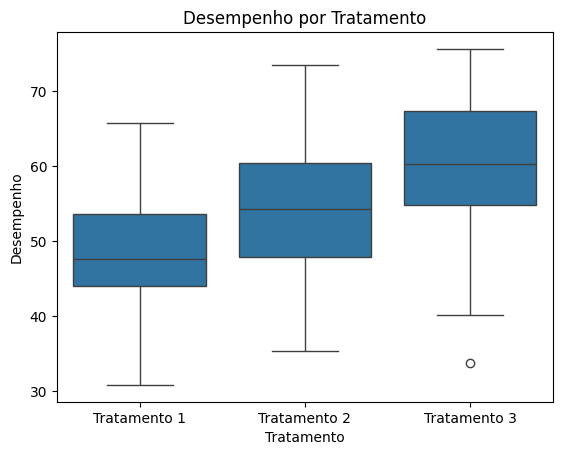

In [63]:
# Visualizando os dados com boxplot
sns.boxplot(x='Tratamento', y='Desempenho', data=df)
plt.title("Desempenho por Tratamento")
plt.show()


In [64]:
# Realizando o teste ANOVA
f_stat, p_value = stats.f_oneway(tratamento_1, tratamento_2, tratamento_3)

# Exibindo o resultado
print(f"Estatística F: {f_stat:.4f}")
print(f"Valor-p: {p_value:.4f}")

# Interpretando o resultado
if p_value < 0.05:
    print("Existe uma diferença significativa entre as médias dos tratamentos.")
else:
    print("Não há diferença significativa entre as médias dos tratamentos.")

Estatística F: 12.2095
Valor-p: 0.0000
Existe uma diferença significativa entre as médias dos tratamentos.


## 5. Correlação de Pearson

- **Objetivo**: Avaliar a relação linear entre duas variáveis contínuas.
- **Quando usar**: Quando deseja medir a força da associação entre duas variáveis que são normalmente distribuídas.
- **Intervalo do coeficiente**: O coeficiente de correlação de Pearson varia de -1 a 1.
  - **1**: Correlação linear positiva perfeita (à medida que uma variável aumenta, a outra também aumenta).
  - **0**: Não há correlação linear entre as variáveis.
  - **-1**: Correlação linear negativa perfeita (à medida que uma variável aumenta, a outra diminui).

### Suposições:
1. **Linearidade**: A relação entre as variáveis deve ser aproximadamente linear.
2. **Normalidade**: As variáveis devem ser normalmente distribuídas.

### Exemplo:
- **Objetivo**: Verificar a relação entre altura e peso de indivíduos.
- **Interpretação**:
  - Um coeficiente próximo de 1 indica uma forte correlação positiva.
  - Um coeficiente próximo de -1 indica uma forte correlação negativa.
  - Se o valor-p for menor que 0,05, a correlação é considerada estatisticamente significativa.



In [72]:
# Exemplo de dados: Altura (em cm) e Peso (em kg)
altura = [150, 160, 170, 180, 190]
peso = [55, 65, 70, 80, 85]

test_shapiro(altura)
test_shapiro(peso)


Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: 0.9671739349728582
Teste de normalidade: não rejeitamos a hipótese nula (os dados parecem seguir uma distribuição normal). p-valor: 0.8989039812387174


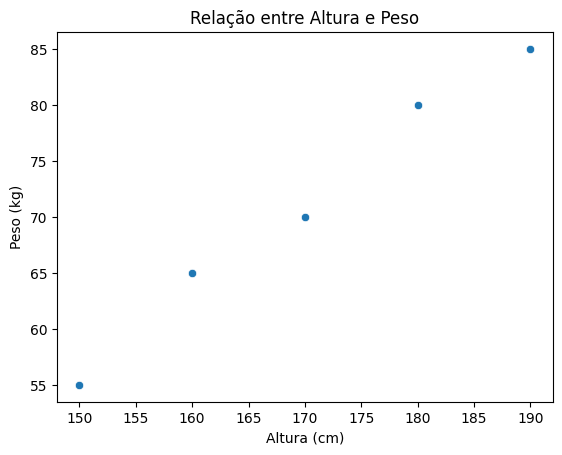

In [73]:
# Visualizando a relação entre as variáveis
sns.scatterplot(x=altura, y=peso)
plt.title("Relação entre Altura e Peso")
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")
plt.show()

In [74]:
# Calculando a correlação de Pearson
correlacao, p_value = stats.pearsonr(altura, peso)

# Exibindo o coeficiente de correlação e o valor-p
print(f"Coeficiente de Correlação de Pearson: {correlacao:.4f}")
print(f"Valor-p: {p_value:.4f}")

# Interpretação
if p_value < 0.05:
    print("Existe uma correlação significativa entre altura e peso.")
else:
    print("Não há correlação significativa entre altura e peso.")

Coeficiente de Correlação de Pearson: 0.9934
Valor-p: 0.0006
Existe uma correlação significativa entre altura e peso.


# Testes Não Paramêtricos 

**Testes não paramétricos** não assumem uma distribuição específica para os dados, sendo mais flexíveis em relação às suposições. Eles são ideais quando os dados não seguem uma distribuição normal ou quando as amostras são pequenas. Exemplos incluem:

- **Teste de Mann-Whitney** (alternativa ao teste T para duas amostras independentes)
- **Teste de Wilcoxon** (para amostras pareadas)
- **Teste de Kruskal-Wallis** (alternativa ao ANOVA)
- **Teste Qui-Quadrado** (para variáveis categóricas)
- **Teste de Kolmogorov-Smirnov**
- **Correlação de Spearman** (alternativa ao person)

## 1. Teste de Mann-Whitney

## 2. Teste Qui-Quadrado (Teste de Independência)

- **Objetivo:** Avaliar se há uma associação significativa entre duas variáveis categóricas, comparando as frequências observadas com as frequências esperadas. Verificando se duas variáveis categóricas são independentes ou têm algum tipo de associação.
- **Exemplo:** Comparar a taxa de ativação de clientes antes e depois de uma ação de marketing, onde a ativação é categorizada como "Ativados" ou "Não Ativados".

#### Hipóteses:

- **Hipótese Nula (H₀):** Não há diferença significativa na taxa de ativação antes e depois da ação de marketing.

  
  $ H_0: \text{Taxa de ativação antes} = \text{Taxa de ativação depois} $

- **Hipótese Alternativa (H₁):** Há uma diferença significativa na taxa de ativação antes e depois da ação de marketing.

  $ H_1: \text{Taxa de ativação antes} \neq \text{Taxa de ativação depois} $

In [94]:
df_mkt = pd.DataFrame({"flg_acao_mkt": ["antes_acao", "depois_acao"],
                        "ativados": [159, 142],
                        "nao_ativados": [886,505]})

df_mkt["tx_ativacao"] = round((df_mkt["ativados"]/(df_mkt["ativados"] + df_mkt["nao_ativados"]))*100,2)
df_mkt

,flg_acao_mkt,ativados,nao_ativados,tx_ativacao
0,antes_acao,159,886,15.22
1,depois_acao,142,505,21.95


In [95]:
df_contingencia = df_mkt[["ativados", "nao_ativados"]]
df_contingencia

,ativados,nao_ativados
0,159,886
1,142,505


In [89]:
chi2, p_avlue, dof, esperados = stats.chi2_contingency(df_contingencia)

# Estrutura condicional para interpretação do resultado
if p_value < 0.05:
    print("Interpretação: como o valor-p de {:.2f}% é menor que o nível de significância de 5%, rejeitamos H₀.".format(p_value * 100))
    print("Há evidência estatística suficiente para afirmar que a taxa de ativação antes da ação de marketing é diferente da taxa de ativação após a ação, indicando que a ação de marketing foi efetiva.")
else:
    print("Interpretação: como o valor-p de {:.2f}% é maior ou igual ao nível de significância de 5%, não rejeitamos H₀.".format(p_value * 100))
    print("Não há evidência estatística suficiente para afirmar que a taxa de ativação antes da ação de marketing é diferente da taxa de ativação após a ação.")

Interpretação: como o valor-p de 0.06% é menor que o nível de significância de 5%, rejeitamos H₀.
Há evidência estatística suficiente para afirmar que a taxa de ativação antes da ação de marketing é diferente da taxa de ativação após a ação, indicando que a ação de marketing foi efetiva.


In [96]:
#valores esperados
esperados

array([[185.90130024, 859.09869976],
       [115.09869976, 531.90130024]])

### Outro exemplo: inadimplência por faixa etária

In [101]:
data = {
    'Faixa Etária': ['Menos de 25', '25-34', '35-44', '45 ou mais'],
    'Inadimplente': [60, 50, 30, 20],
    'Não Inadimplente': [160, 150, 170, 180]
}

df_idade = pd.DataFrame(data)
df_idade.set_index('Faixa Etária', inplace=True)
df_idade["Taxa Inadimplente"] = round((df_idade["Inadimplente"]/(df_idade["Inadimplente"] + df_idade["Não Inadimplente"]))*100,2)

df_idade

,Inadimplente,Não Inadimplente,Taxa Inadimplente
Faixa Etária,,,
Menos de 25,60,160,27.27
25-34,50,150,25.00
35-44,30,170,15.00
45 ou mais,20,180,10.00


In [109]:
array_contingencia = np.array(df_idade[["Inadimplente", "Não Inadimplente"]])

array([[ 60, 160],
       [ 50, 150],
       [ 30, 170],
       [ 20, 180]])

In [112]:
chi2, p_avlue, dof, esperados = stats.chi2_contingency(observed=array_contingencia)

# Estrutura condicional para interpretação do resultado
if p_value < 0.05:
    print("Interpretação: como o valor-p de {:.2f}% é menor que o nível de significância de 5%, rejeitamos H₀.".format(p_value * 100))
    print("Há evidência estatística suficiente para afirmar que a taxa de inadimplência é dependente da faixa etária dos clientes.")
else:
    print("Interpretação: como o valor-p de {:.2f}% é maior ou igual ao nível de significância de 5%, não rejeitamos H₀.".format(p_value * 100))
    print("Não há evidência estatística suficiente para afirmar que a taxa de inadimplência é dependente da faixa etária dos clientes.")

Interpretação: como o valor-p de 0.06% é menor que o nível de significância de 5%, rejeitamos H₀.
Há evidência estatística suficiente para afirmar que a taxa de inadimplência é dependente da faixa etária dos clientes.


In [113]:
esperados

array([[ 42.92682927, 177.07317073],
       [ 39.02439024, 160.97560976],
       [ 39.02439024, 160.97560976],
       [ 39.02439024, 160.97560976]])

## 3. Teste de Wilcoxon

## 4. Teste de Kruskal-Wallis

## 5. Teste de Kolmogorov-Smirnov

## 6. Correlação de Spearman

In [1]:
#teste qui quadrado de aderencia
#corrigir p-valor do teste qui quadrado